# LEO Annotations / ScanNet / 3RScan Data Check

Exploratory notebook: peek at LEO's alignment/instruction annotations, cross-reference `scan_id` against local ScanNet `posed_images` and 3RScan `sequence` frames, and attempt a `target_id -> 2D bbox` conversion via `{id}-label.npy`.

**Adjust the path config in the first cell to match your actual cluster layout before running.**

In [1]:
import json, random
from pathlib import Path
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# --- path config -- adjust these to your actual layout ---
ROOT = Path("/glob/g01-cache/pf/Yushuo/vjepa201")
LEO_ANNO = ROOT / "source_data/leo_annotations/annotations"
SCANNET_POSED = Path("/glob/g01-cache/pf/Yushuo/vjepa201/source_data/scannet/posed_images")  # TODO: confirm this matches your scannet mount
SCANNET_SCANS = ROOT / "source_data/scannet/scans"  # official raw release: scans/<scan_id>/instance-filt/<frame_num>.png
THREERSCAN_ROOT = ROOT / "source_data/3rscan"

def load_json(p):
    with open(p, encoding="utf-8") as f:
        return json.load(f)


## 1. LEO annotations -- random instance peek

Loads the ScanNet-anchored + 3RScan-anchored annotation files and prints a couple random rows from each so you can eyeball the schema.

In [3]:
FILES = {
    "scanrefer_train":  LEO_ANNO / "instruction/scan2cap/scanrefer_train.json",
    "nr3d":             LEO_ANNO / "alignment/obj_scene_caption/scannet_referit3d_nr3d_train.json",
    "sr3d+":            LEO_ANNO / "alignment/obj_scene_caption/scannet_referit3d_sr3d+_train.json",
    "3rscan_scenecap":  LEO_ANNO / "alignment/scene_caption/3rscan_scenecap_train.json",
}

loaded = {}
for name, path in FILES.items():
    if not path.exists():
        print(f"[skip] {name}: not found at {path}")
        continue
    data = load_json(path)
    loaded[name] = data
    kind = "list" if isinstance(data, list) else "dict (keyed by scan_id)"
    print(f"{name}: {len(data)} entries, {kind}")


scanrefer_train: 36665 entries, list
nr3d: 30037 entries, list
sr3d+: 90450 entries, list
3rscan_scenecap: 1178 entries, dict (keyed by scan_id)


In [4]:
def _print_row(row, skip_keys=("query", "tokens", "enc_tokens")):
 """Print all fields in full except the long/uninteresting ones (query is
 just the LLM prompt used to generate `response`, tokens/enc_tokens are
 leftover tokenization from LEO's own model -- not useful here)."""
 for k, v in row.items():
     if k in skip_keys:
         print(f"  {k}: <skipped, len={len(str(v))}>")
     else:
         print(f"  {k}: {v}")

for name, data in loaded.items():
 print(f"\n=== {name} ===")
 if isinstance(data, list):
     for row in random.sample(data, min(3, len(data))):
         _print_row(row)
         print("---")
 else:  # dict keyed by scan_id (3rscan_scenecap)
     for scan_id in random.sample(list(data.keys()), min(2, len(data))):
         entries = data[scan_id]
         print(f"scan_id={scan_id}, {len(entries)} caption variants (different ratio/random_id)")
         _print_row(random.choice(entries))
         print("---")


=== scanrefer_train ===
  item_id: scanrefer_train_029567
  scan_id: scene0542_00
  target_id: 11
  instance_type: kitchen counter
  utterance: a white counter top. covering the cabinets.
  tokens: <skipped, len=73>
  enc_tokens: <skipped, len=65>
  ann_id: 1
---
  item_id: scanrefer_train_008984
  scan_id: scene0167_00
  target_id: 17
  instance_type: footrest
  utterance: the footrest is color wine/red. the footrest is besides the couch.
  tokens: <skipped, len=116>
  enc_tokens: <skipped, len=114>
  ann_id: 2
---
  item_id: scanrefer_train_021342
  scan_id: scene0409_00
  target_id: 10
  instance_type: dining table
  utterance: the dining table is white. it is surrounded by red chairs.
  tokens: <skipped, len=100>
  enc_tokens: <skipped, len=88>
  ann_id: 4
---

=== nr3d ===
  item_id: nr3d_036048
  stimulus_id: scene0273_00-table-5-8-6-7-9-10
  scan_id: scene0273_00
  instance_type: table
  target_id: 8
  utterance: the table at the end of the red couches that ARE NOT against the 

## 2. Cross-reference with ScanNet / 3RScan -- locate frames + visualize

`scan_id` in ScanRefer/Nr3D/Sr3D+ rows is a ScanNet id (`sceneXXXX_XX`) -> look up `SCANNET_POSED/<scan_id>/`.
`scan_id` in `3rscan_scenecap` is a 3RScan UUID -> look up `THREERSCAN_ROOT/<scan_id>/sequence/`.

In [5]:
def scannet_frames(scan_id, root=SCANNET_POSED):
  scene_dir = root / scan_id
  if not scene_dir.exists():
      return []
  return sorted(
      p for p in scene_dir.glob("*.jpg")
      if "-annotated" not in p.stem
  )

def rscan_frames(scan_id, root=THREERSCAN_ROOT):
    seq_dir = root / scan_id / "sequence"
    if not seq_dir.exists():
        return []
    # 3RScan sequence.zip layout not yet confirmed -- if this returns nothing,
    # run `list(seq_dir.glob("*"))[:20]` to see actual filenames and fix the pattern.
    return sorted(seq_dir.glob("*color*"))


scan_id=scene0268_00  target_id=19
utterance: a small rectangular garbage bin in the corner of the bathroom.  it is under the toilet paper roll, to the right of the toilet.
found 84 posed_images frames for this scene


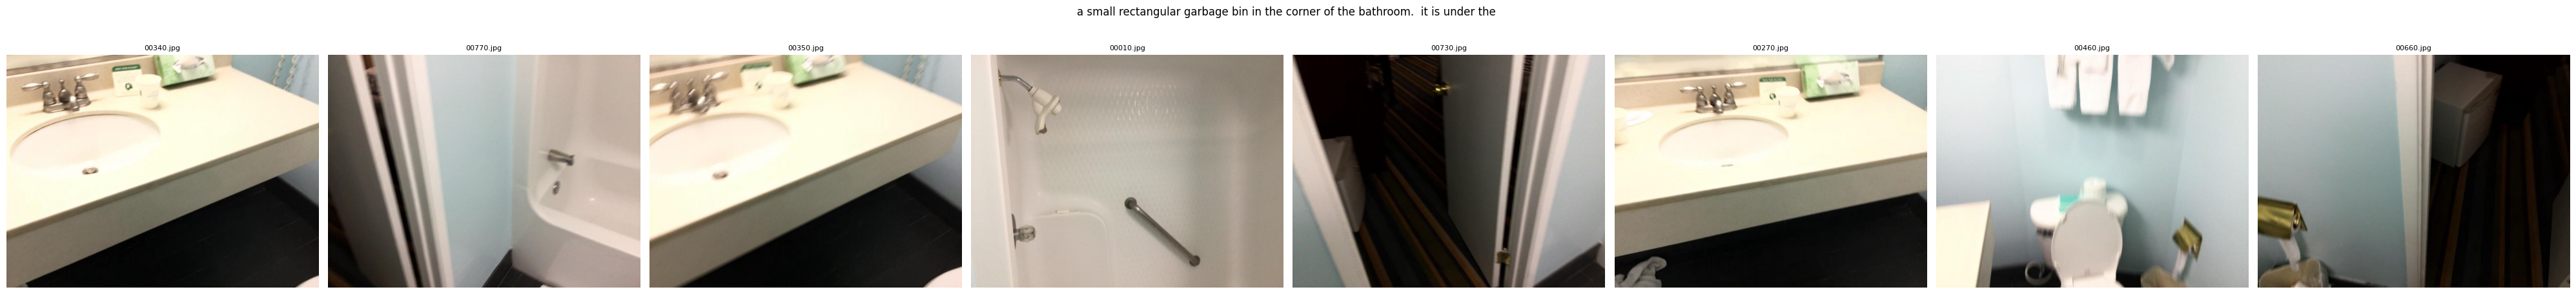

In [6]:
# --- ScanNet-anchored example (ScanRefer) ---
row = random.choice(loaded["scanrefer_train"])
scan_id, target_id, utterance = row["scan_id"], row["target_id"], row["utterance"]
print(f"scan_id={scan_id}  target_id={target_id}")
print(f"utterance: {utterance}")

frames = scannet_frames(scan_id)
print(f"found {len(frames)} posed_images frames for this scene")

sample_frames = random.sample(frames, min(8, len(frames))) if frames else []
if sample_frames:
    fig, axes = plt.subplots(1, len(sample_frames), figsize=(5 * len(sample_frames), 5))
    if len(sample_frames) == 1:
        axes = [axes]
    for ax, fp in zip(axes, sample_frames):
        ax.imshow(Image.open(fp).convert("RGB"))
        ax.set_title(fp.name, fontsize=8)
        ax.axis("off")
    plt.suptitle(utterance[:80])
    plt.tight_layout()
    plt.show()
else:
    print("no frames found -- check SCANNET_POSED path / scan_id naming")


scan_id=d7d40d66-7a5d-2b36-941c-8c8d61e4e0ab
response: In a white room with tiled ceramic floor, there is a tall white rectangular shelf standing on the floor. It is messy and located in front of a white cupboard, behind another white cupboard, and to the right of a white garbage bin and a white chair. There is also a brown rectangular box on the cupboa
found 363 frames via rscan_frames() pattern


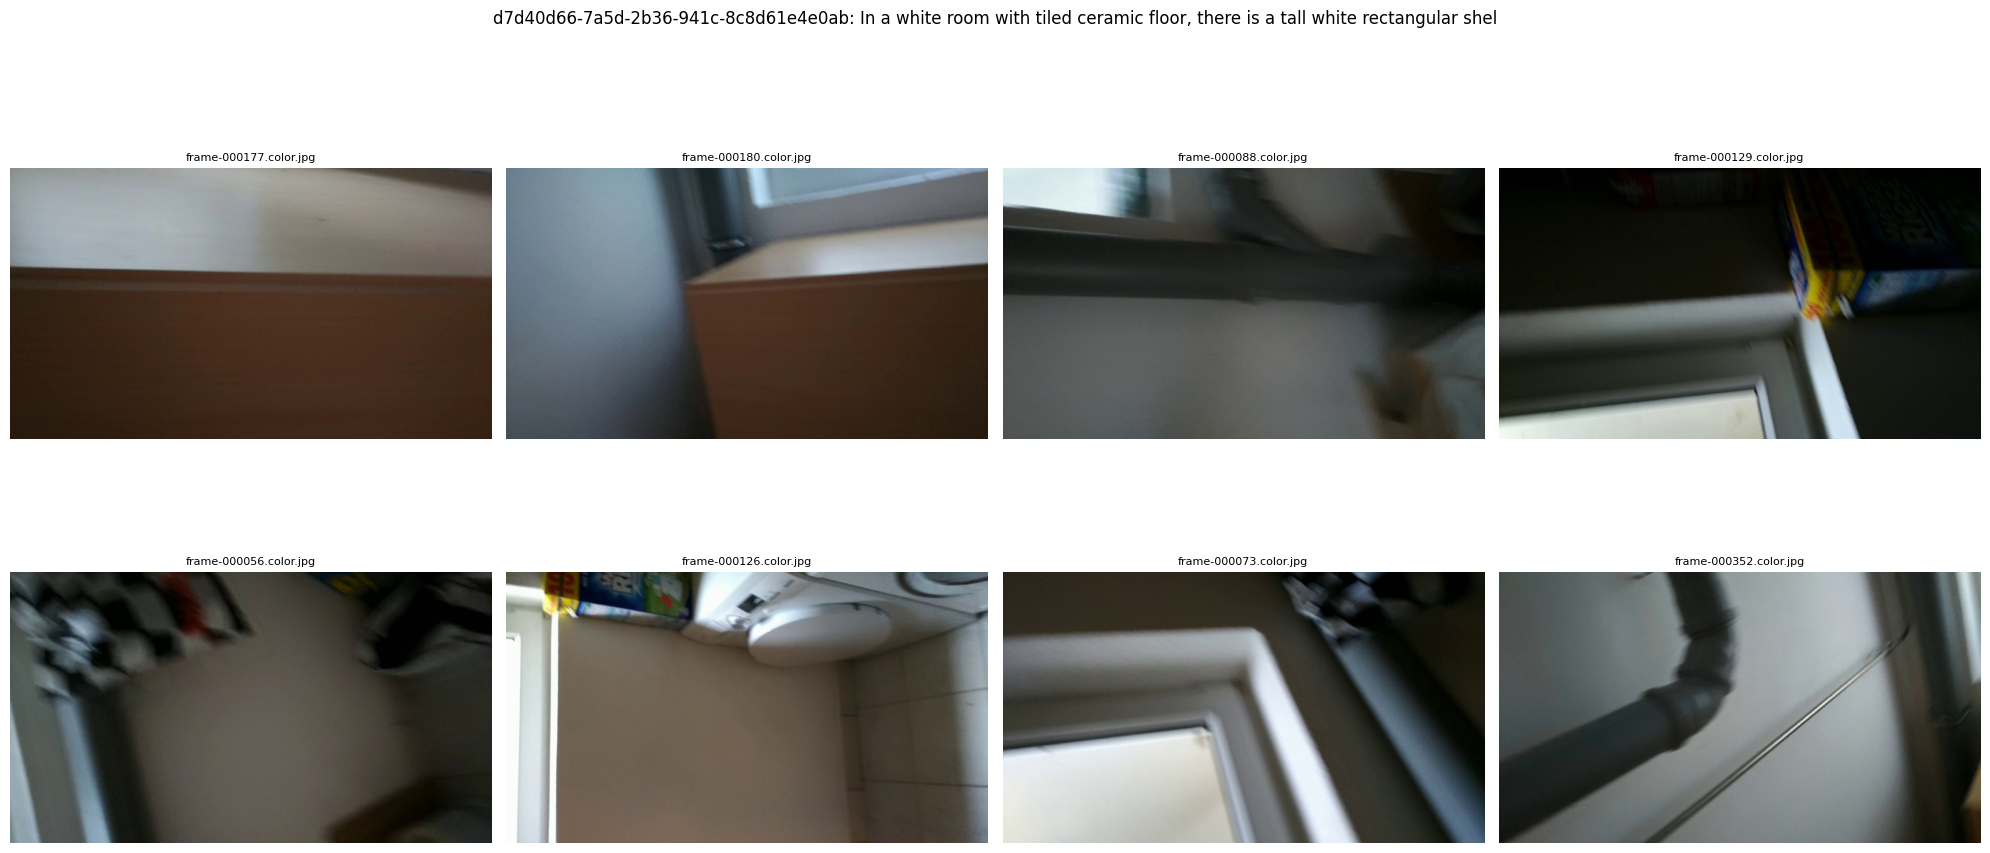

In [7]:
scan_id = random.choice(list(loaded["3rscan_scenecap"].keys()))
entry = random.choice(loaded["3rscan_scenecap"][scan_id])
print(f"scan_id={scan_id}")
print("response:", entry["response"][:300])

frames = rscan_frames(scan_id)
print(f"found {len(frames)} frames via rscan_frames() pattern")

seq_dir = THREERSCAN_ROOT / scan_id / "sequence"
if not frames and seq_dir.exists():
  print("pattern matched nothing -- actual files in sequence/:")
  print(list(seq_dir.glob("*"))[:20])
elif frames:
  sample_frames = random.sample(frames, min(8, len(frames)))
  n_cols = 4
  n_rows = 2
  fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
  axes = axes.flatten()
  for ax, fp in zip(axes, sample_frames):
      ax.imshow(Image.open(fp).convert("RGB"))
      ax.set_title(fp.name, fontsize=8)
      ax.axis("off")
  for ax in axes[len(sample_frames):]:
      ax.axis("off")
  plt.suptitle(f"{scan_id}: {entry['response'][:80]}")
  plt.tight_layout()
  plt.show()


In [8]:
row = random.choice(loaded["scanrefer_train"])
scan_id, target_id = row["scan_id"], row["target_id"]
frames = scannet_frames(scan_id)

if frames:
    label_path = frames[0].with_name(frames[0].stem + "-label.npy")
    if label_path.exists():
        label = np.load(label_path)
        print("label.npy shape:", label.shape, "dtype:", label.dtype)
        print("unique values (first 20):", np.unique(label)[:20])
        print(f"this row's target_id = {target_id} -- is it among the unique values above?")
    else:
        print(f"no label.npy next to {frames[0].name} -- check the naming convention (expected '{frames[0].stem}-label.npy')")
else:
    print(f"no frames found for {scan_id}")


label.npy shape: (968, 1296) dtype: uint8
unique values (first 20): [ 0 10 13 14 21 23 24 26 27 28]
this row's target_id = 12 -- is it among the unique values above?


In [15]:
scan_id = row["scan_id"]  # 用同一个scan_id, 别换
frames = scannet_frames(scan_id)
all_values = set()
for fp in frames:
  label_path = fp.with_name(fp.stem + "-label.npy")
  if label_path.exists():
      all_values |= set(np.unique(np.load(label_path)).tolist())

print(f"全场景{len(frames)}帧, 一共出现过{len(all_values)}个不同的label值")
print(f"target_id={target_id} 在不在里面: {target_id in all_values}")

全场景128帧, 一共出现过26个不同的label值
target_id=29 在不在里面: False


In [22]:

npz_path = frames[0].with_name(frames[0].stem + "-overlap.npz")
data = np.load(npz_path, allow_pickle=True)
print("keys:", data.files)

indices = data["indices"]
box_lists = data["box_lists"]
print("indices:", indices.shape, indices.dtype)
print("box_lists type:", type(box_lists), "shape:", box_lists.shape if hasattr(box_lists,
"shape") else len(box_lists))

# box_lists大概率是object数组, 逐个元素看结构
print(box_lists[0])
print(box_lists[:3])
scan_id = row["scan_id"]
frames = scannet_frames(scan_id)
all_values = set()
for fp in frames:
  npz_path = fp.with_name(fp.stem + "-overlap.npz")
  if npz_path.exists():
      d = np.load(npz_path, allow_pickle=True)
      for entry in d["box_lists"]:
          all_values.update(entry)

print(f"全场景{len(frames)}帧, overlap.npz里一共出现过{len(all_values)}个不同的值")
print(f"target_id={target_id} 在不在里面: {target_id in all_values}")

keys: ['indices', 'box_lists']
indices: (209428, 2) int32
box_lists type: <class 'numpy.ndarray'> shape: (209428,)
[13, 6]
[list([13, 6]) list([13, 6]) list([13, 6])]
全场景128帧, overlap.npz里一共出现过22个不同的值
target_id=29 在不在里面: False


In [ ]:
def target_bbox_in_frame(frame_path, target_id):
    """Best-effort: assumes {id}-label.npy is a per-pixel instance-id map
    whose values line up with ScanRefer/Nr3D/Sr3D+ target_id numbering.
    Verify against the cell above first -- if the assumption is wrong (e.g.
    semantic classes instead of instances), this silently returns None for
    everything, or matches the wrong region.
    """
    label_path = frame_path.with_name(frame_path.stem + "-label.npy")
    if not label_path.exists():
        return None
    label = np.load(label_path)
    ys, xs = np.where(label == target_id)
    if len(xs) == 0:
        return None
    return [int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())]


row = random.choice(loaded["scanrefer_train"])
scan_id, target_id, utterance = row["scan_id"], row["target_id"], row["utterance"]
frames = scannet_frames(scan_id)

found = None
for fp in frames:
    box = target_bbox_in_frame(fp, target_id)
    if box is not None:
        found = (fp, box)
        break

if found is None:
    print(f"target_id={target_id} not found in any sampled frame for {scan_id} -- "
          f"could be normal (object not visible in this scene's posed_images subsample), "
          f"or label.npy isn't instance-indexed the way assumed above. Try a different row "
          f"or re-run the cell (random row each time) if this keeps happening.")
else:
    fp, box = found
    print(f"found in {fp.name}, box={box}")
    img = Image.open(fp).convert("RGB")
    draw = ImageDraw.Draw(img)
    draw.rectangle(box, outline="red", width=3)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(utterance[:80])
    plt.axis("off")
    plt.show()


In [ ]:
# Retry a few times if the random row above missed -- quick loop to find one that hits.
for _ in range(20):
    row = random.choice(loaded["scanrefer_train"])
    scan_id, target_id, utterance = row["scan_id"], row["target_id"], row["utterance"]
    frames = scannet_frames(scan_id)
    hit = None
    for fp in frames:
        box = target_bbox_in_frame(fp, target_id)
        if box is not None:
            hit = (fp, box)
            break
    if hit:
        fp, box = hit
        print(f"scan_id={scan_id} target_id={target_id} -> {fp.name} box={box}")
        img = Image.open(fp).convert("RGB")
        draw = ImageDraw.Draw(img)
        draw.rectangle(box, outline="lime", width=3)
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(utterance[:80])
        plt.axis("off")
        plt.show()
        break
else:
    print("no hit in 20 tries -- worth revisiting the label.npy format assumption in section 3's first cell.")


## 4. `target_id` -> mask/bbox via official `_2d-instance-filt.zip`

Section 3's `{id}-label.npy` assumption failed (`target_id=29` wasn't even
among the 26 label values seen across the whole scene). ScanRefer/Nr3D/Sr3D+'s
`target_id` is defined as the ScanNet `objectId` from `.aggregation.json`, and
`_2d-instance-filt.zip` (official kaldir release, downloaded via
`dataset/download_scannet_2d_instance.sh`) is ScanNet's own per-frame instance
mask rendered from that same `objectId` numbering -- so pixel value should
equal `target_id` directly, unlike the HF-mirror `label.npy` whose indexing
convention is unconfirmed/wrong.

Layout: `SCANNET_SCANS/<scan_id>/instance-filt/<frame_num>.png`, `frame_num`
an **unpadded** raw `.sens` frame index (`10.png`, not `00010.png`) -- same
underlying frame numbering as `posed_images/<scan_id>/00010.jpg`, just not
zero-padded and not necessarily subsampled at the same stride. The first cell
below checks the actual overlap before assuming every posed frame has a match.

In [9]:
def instance_filt_dir(scan_id, root=SCANNET_SCANS):
    return root / scan_id / "instance-filt"


def instance_filt_frame_numbers(scan_id):
    """Numerically-sorted raw frame indices actually present in instance-filt/."""
    d = instance_filt_dir(scan_id)
    if not d.exists():
        return []
    return sorted(int(p.stem) for p in d.glob("*.png"))


def posed_frame_numbers(scan_id):
    """Raw frame indices implied by posed_images/<scan_id>/NNNNN.jpg (stride-10 zero-padded)."""
    return sorted(int(p.stem) for p in scannet_frames(scan_id))


def nearest_instance_filt_path(scan_id, frame_num, available=None):
    """posed_images and instance-filt aren't guaranteed to share a stride --
    snap to the closest available instance-filt frame number instead of
    requiring an exact match."""
    if available is None:
        available = instance_filt_frame_numbers(scan_id)
    if not available:
        return None
    closest = min(available, key=lambda n: abs(n - frame_num))
    return instance_filt_dir(scan_id) / f"{closest}.png"


# --- coverage check: pick one scan_id, compare posed_images vs instance-filt frame numbers ---
row = random.choice(loaded["scanrefer_train"])
scan_id = row["scan_id"]

posed_nums = posed_frame_numbers(scan_id)
inst_nums = instance_filt_frame_numbers(scan_id)
print(f"scan_id={scan_id}")
print(f"posed_images: {len(posed_nums)} frames, range {posed_nums[:1]}..{posed_nums[-1:]}" if posed_nums else "posed_images: none found")
print(f"instance-filt: {len(inst_nums)} frames, range {inst_nums[:1]}..{inst_nums[-1:]}" if inst_nums else "instance-filt: none found -- run dataset/download_scannet_2d_instance.sh for this scan_id first")

if posed_nums and inst_nums:
    inst_set = set(inst_nums)
    exact = sum(1 for n in posed_nums if n in inst_set)
    print(f"exact frame-number matches: {exact}/{len(posed_nums)} posed frames")
    sample_gaps = [abs(n - min(inst_nums, key=lambda x: abs(x - n))) for n in posed_nums[:10]]
    print(f"nearest-neighbor gap for first 10 posed frames: {sample_gaps}")
    print("(if exact match count is low, instance-filt uses a different stride -- "
          "nearest_instance_filt_path() below snaps to the closest one instead)")


scan_id=scene0184_00
posed_images: 321 frames, range [0]..[3200]
instance-filt: 3206 frames, range [0]..[3205]
exact frame-number matches: 321/321 posed frames
nearest-neighbor gap for first 10 posed frames: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
(if exact match count is low, instance-filt uses a different stride -- nearest_instance_filt_path() below snaps to the closest one instead)


In [10]:
# --- exhaustive check, same shape as section 3's label.npy check: scan every
# instance-filt frame for this scan_id, collect the full set of instance ids
# actually rendered, and see whether target_id shows up anywhere. ---
row = random.choice(loaded["scanrefer_train"])
scan_id, target_id = row["scan_id"], row["target_id"]

inst_nums = instance_filt_frame_numbers(scan_id)
all_ids = set()
for n in inst_nums:
    mask = np.array(Image.open(instance_filt_dir(scan_id) / f"{n}.png"))
    all_ids |= set(np.unique(mask).tolist())

print(f"scan_id={scan_id}, {len(inst_nums)} instance-filt frames, {len(all_ids)} distinct instance ids seen")
print(f"target_id={target_id} in there: {target_id in all_ids}")
print(f"all ids: {sorted(all_ids)}")


scan_id=scene0506_00, 857 instance-filt frames, 19 distinct instance ids seen
target_id=1 in there: True
all ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]


hit rate: 30/30 rows found target_id in some instance-filt frame


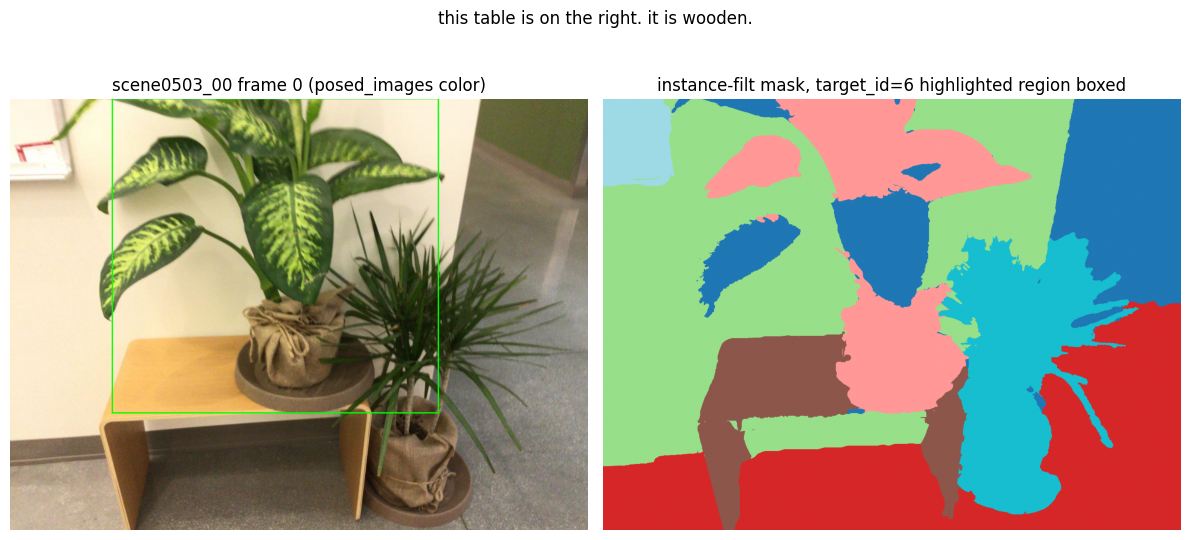

In [12]:
def target_bbox_via_instance_filt(scan_id, frame_num, target_id, available=None):
    """Like section 3's target_bbox_in_frame(), but reading the official
    instance-filt mask (pixel value == objectId) instead of label.npy."""
    p = nearest_instance_filt_path(scan_id, frame_num, available=available)
    if p is None or not p.exists():
        return None
    mask = np.array(Image.open(p))
    ys, xs = np.where(mask == target_id)
    if len(xs) == 0:
        return None
    return [int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())], mask


# Retry across random rows until one hits, same pattern as section 3's retry
# loop -- but report the hit rate this time so we know whether this actually
# works better than label.npy did.
hits, tries = 0, 30
last_hit = None
for _ in range(tries):
    row = random.choice(loaded["scanrefer_train"])
    scan_id, target_id, utterance = row["scan_id"], row["target_id"], row["utterance"]
    inst_nums = instance_filt_frame_numbers(scan_id)
    if not inst_nums:
        continue
    for pn in posed_frame_numbers(scan_id):
        result = target_bbox_via_instance_filt(scan_id, pn, target_id, available=inst_nums)
        if result is not None:
            hits += 1
            last_hit = (scan_id, target_id, utterance, pn, *result)
            break

print(f"hit rate: {hits}/{tries} rows found target_id in some instance-filt frame")

if last_hit:
    scan_id, target_id, utterance, pn, box, mask = last_hit
    color_path = SCANNET_POSED / scan_id / f"{pn:05d}.jpg"
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    if color_path.exists():
        img = Image.open(color_path).convert("RGB")
        draw = ImageDraw.Draw(img)
        draw.rectangle(box, outline="lime", width=3)
        axes[0].imshow(img)
        axes[0].set_title(f"{scan_id} frame {pn} (posed_images color)")
    else:
        axes[0].set_title(f"no posed_images color frame at {pn}")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="tab20")
    axes[1].set_title(f"instance-filt mask, target_id={target_id} highlighted region boxed")
    axes[1].axis("off")
    plt.suptitle(utterance[:100])
    plt.tight_layout()
    plt.show()
else:
    print("no hits at all -- check SCANNET_SCANS path and that "
          "dataset/download_scannet_2d_instance.sh has actually populated "
          "instance-filt/ for these scan_ids yet.")
